In [1]:
from pathlib import Path
import io
import zipfile
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")


In [2]:
dataset_path = Path("bank.csv")

if dataset_path.exists():
    df = pd.read_csv(dataset_path, sep=";")
else:
    bank_marketing_url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"

    with urlopen(bank_marketing_url) as response:
        outer_zip_bytes = io.BytesIO(response.read())

    with zipfile.ZipFile(outer_zip_bytes) as outer_zip:
        with outer_zip.open("bank.zip") as nested_zip_file:
            nested_zip_bytes = io.BytesIO(nested_zip_file.read())

    with zipfile.ZipFile(nested_zip_bytes) as nested_zip:
        with nested_zip.open("bank.csv") as csv_file:
            df = pd.read_csv(csv_file, sep=";")

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Dataset loaded successfully with 4521 rows and 17 columns.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


# Dataset information


In [3]:
print("DATASET INFO ")
df.info()
print("\nMissing values in each column:\n", df.isnull().sum())


print("\n TARGET VARIABLE DISTRIBUTION ('y') ")
target_counts = df['y'].value_counts()
print(target_counts)
print(f"\nPercentage of 'yes': {(target_counts['yes'] / len(df)) * 100:.2f}%")

DATASET INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB

Missing values in each column:
 age          0
job          0
marital      0
educati

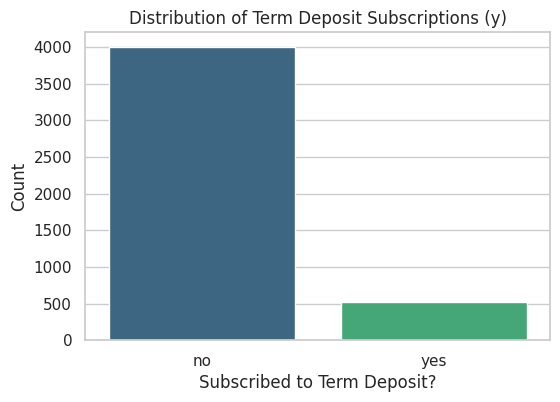

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='viridis')
plt.title('Distribution of Term Deposit Subscriptions (y)')
plt.xlabel('Subscribed to Term Deposit?')
plt.ylabel('Count')
plt.show()

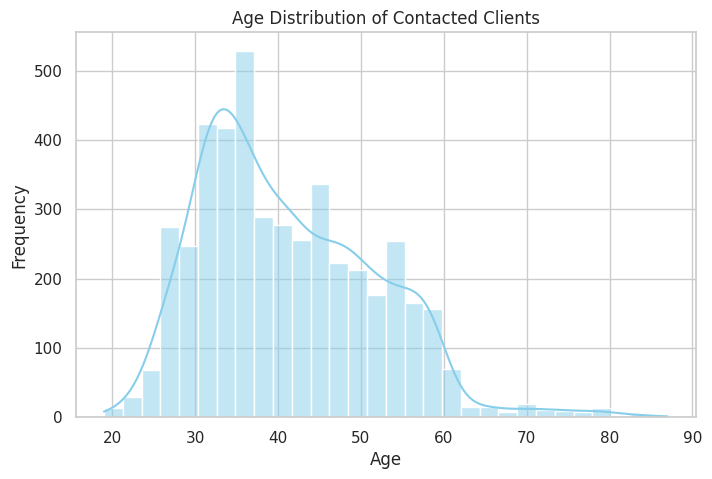

In [5]:

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Contacted Clients')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

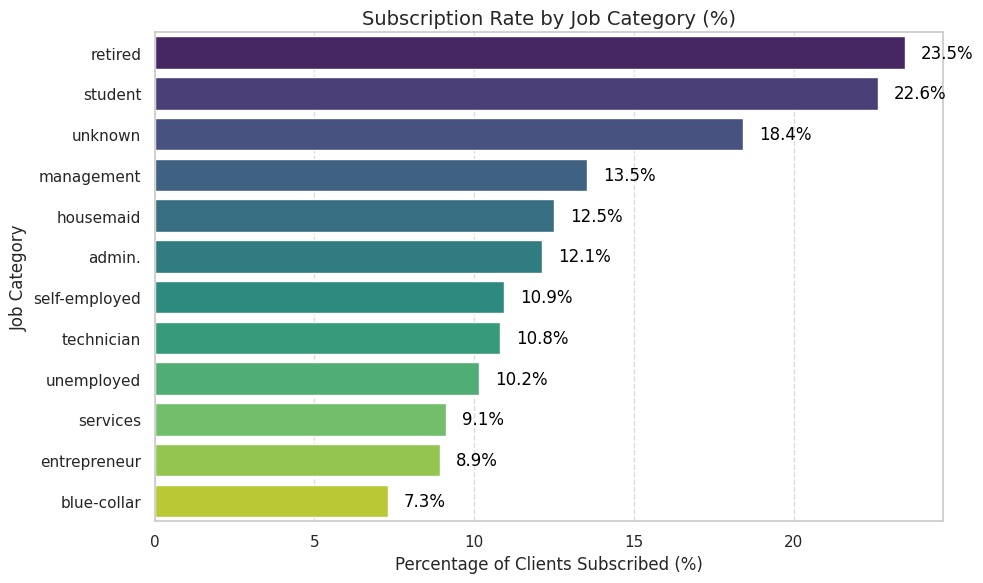

In [6]:
# Calculate the percentage of 'yes' for each job category
job_conversion = df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=job_conversion.values, y=job_conversion.index, palette='viridis')

plt.title('Subscription Rate by Job Category (%)', fontsize=14)
plt.xlabel('Percentage of Clients Subscribed (%)', fontsize=12)
plt.ylabel('Job Category', fontsize=12)

# Add percentage labels to the bars
for i, v in enumerate(job_conversion.values):
    plt.text(v + 0.5, i, f'{v:.1f}%', color='black', va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Task start of gemini ai contribution
Perform data quality assessment on the bank marketing dataset loaded from "bank.csv". Specifically, identify and count duplicate rows in the DataFrame `df`, examine unique values in categorical columns like 'job', 'education', and 'poutcome' to check for 'unknown' placeholders, and use descriptive statistics or box plots to detect potential outliers in numerical columns such as 'balance', 'duration', and 'campaign'. Summarize these findings to determine if the data is ready for further preprocessing.

**Reasoning**:
Checking for and handling duplicate rows in the DataFrame to ensure data integrity as per the instructions.



In [7]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# If duplicates exist, remove them
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows have been removed.")
else:
    print("No duplicate rows to remove.")

# Verify the new shape of the DataFrame
print(f"Updated DataFrame shape: {df.shape}")

Number of duplicate rows found: 0
No duplicate rows to remove.
Updated DataFrame shape: (4521, 17)


## Analyze Categorical Consistency

### Subtask:
Examine unique values for categorical columns such as 'job', 'education', and 'poutcome' to identify 'unknown' or placeholder values that may require handling.


**Reasoning**:
I will inspect the specified categorical columns to identify and quantify the presence of 'unknown' placeholder values, as required by the subtask instructions.



In [8]:
# Define the categorical columns to inspect
categorical_cols = ['job', 'education', 'poutcome']

print("--- Categorical Consistency Analysis ---\n")

for col in categorical_cols:
    # Retrieve unique value counts
    counts = df[col].value_counts()

    # Identify 'unknown' count
    unknown_count = counts.get('unknown', 0)
    total_rows = len(df)
    unknown_percentage = (unknown_count / total_rows) * 100

    print(f"Column: {col}")
    print(counts)
    print(f"'unknown' values: {unknown_count} ({unknown_percentage:.2f}% of total)")
    print("-" * 30)

--- Categorical Consistency Analysis ---

Column: job
job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64
'unknown' values: 38 (0.84% of total)
------------------------------
Column: education
education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64
'unknown' values: 187 (4.14% of total)
------------------------------
Column: poutcome
poutcome
unknown    3705
failure     490
other       197
success     129
Name: count, dtype: int64
'unknown' values: 3705 (81.95% of total)
------------------------------


## Outlier Detection

### Subtask:
Identify potential outliers in numerical columns like 'balance', 'duration', and 'campaign' using box plots or descriptive statistics.


**Reasoning**:
I will calculate descriptive statistics and create box plots for 'balance', 'duration', and 'campaign' to identify potential outliers as per the subtask instructions.



--- Descriptive Statistics for Outlier Detection ---


,balance,duration,campaign
count,4521.000000,4521.000000,4521.000000
mean,1422.657819,263.961292,2.793630
std,3009.638142,259.856633,3.109807
min,-3313.000000,4.000000,1.000000
25%,69.000000,104.000000,1.000000
50%,444.000000,185.000000,2.000000
75%,1480.000000,329.000000,3.000000
max,71188.000000,3025.000000,50.000000


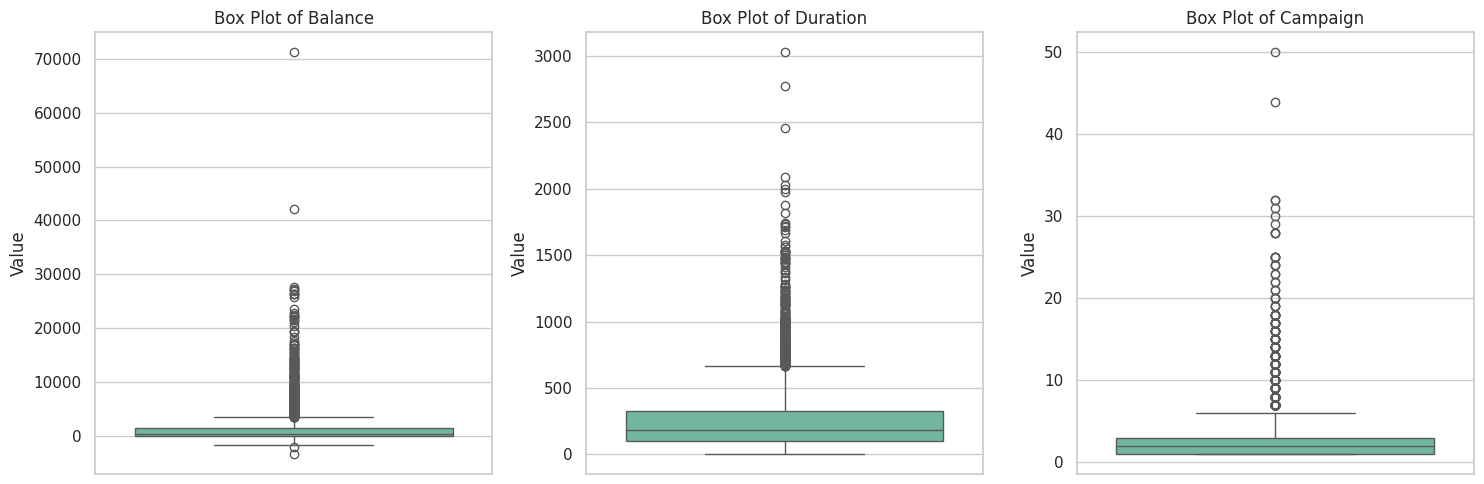

Balance: Found 506 potential outliers based on IQR method.
Duration: Found 330 potential outliers based on IQR method.
Campaign: Found 318 potential outliers based on IQR method.


In [9]:
# 1. Define numerical columns to inspect
num_cols = ['balance', 'duration', 'campaign']

# 2. Generate summary statistics
print("--- Descriptive Statistics for Outlier Detection ---")
display(df[num_cols].describe())

# 3. Create subplots for box plots
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], palette='Set2')
    plt.title(f'Box Plot of {col.capitalize()}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

# 4. Preliminary Analysis printout
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))]
    print(f"{col.capitalize()}: Found {len(outliers)} potential outliers based on IQR method.")

In [10]:
# Confirming duration measurement
print(f"Min duration: {df['duration'].min()}s")
print(f"Max duration: {df['duration'].max()}s")
print(f"Average duration: {df['duration'].mean():.2f}s")

# Show first few values
display(df[['duration']].head())

Min duration: 4s
Max duration: 3025s
Average duration: 263.96s


,duration
0,79
1,220
2,185
3,199
4,226


### Data Quality Assessment Summary

Based on the analysis performed, here are the key findings:

1.  **Duplicates**: No duplicate rows were found in the dataset, ensuring basic data integrity.
2.  **Categorical Consistency**:
    *   **Job**: 0.84% (38) are 'unknown'.
    *   **Education**: 4.14% (187) are 'unknown'.
    *   **Poutcome**: 81.95% (3,705) are 'unknown'. This high percentage indicates that the majority of clients were not part of previous campaigns, which is a critical insight for feature engineering.
3.  **Outliers**:
    *   **Balance**: 506 outliers found (max: 71,188). These may need scaling or clipping.
    *   **Duration**: 330 outliers found. Note that duration highly affects the output target (e.g., if duration=0 then y='no').
    *   **Campaign**: 318 outliers found (max: 50 contacts).

**Conclusion**: The data is generally clean but contains significant outliers and a large amount of missing information in 'poutcome'. It is ready for preprocessing steps such as encoding and scaling.

## Final Task

### Subtask:
Summarize the data quality findings and confirm the dataset's readiness for further preprocessing and modeling.


## Summary:

### Q&A

**Is the dataset ready for further preprocessing and modeling?**
Yes, the dataset is ready. While it is free of duplicate rows, the assessment identified specific areas—such as extreme outliers in numerical columns and a high volume of "unknown" values in the `poutcome` feature—that must be addressed during the preprocessing stage through scaling, clipping, or feature engineering.

### Data Analysis Key Findings

*   **Data Integrity**: The dataset contains **0 duplicate rows**, maintaining a consistent shape of (4521, 17).
*   **Categorical Placeholders**:
    *   The `poutcome` (previous campaign outcome) column is heavily masked, with **81.95% (3,705 values)** labeled as 'unknown'.
    *   `job` and `education` have relatively low "unknown" rates at **0.84%** and **4.14%** respectively.
*   **Numerical Outliers (IQR Method)**:
    *   **Balance**: **506 outliers** detected, with a maximum value of \$71,188 compared to a mean of \$1,422.66.
    *   **Duration**: **330 outliers** detected; some calls lasted up to 3,025 seconds (~50 minutes), significantly higher than the 75th percentile of 329 seconds.
    *   **Campaign**: **318 outliers** detected, with some clients being contacted up to 50 times during the campaign.

### Insights or Next Steps

*   **Feature Engineering for `poutcome`**: Given that over 80% of the data is 'unknown', this column should either be dropped or transformed into a binary feature (e.g., "previously contacted" vs "not contacted") to avoid noise in the model.
*   **Robust Scaling**: Due to the high number of outliers and significant skewness in `balance` and `duration`, standard normalization may be ineffective; using a RobustScaler or applying log transformations is recommended to minimize the influence of extreme values.


End of AI contribution

In [11]:
df_model = df.drop_duplicates().copy()
df_model = df_model.drop(columns=["duration"])

X = df_model.drop(columns=["y"]).copy()
y = LabelEncoder().fit_transform(df_model["y"])

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

X[categorical_cols] = X[categorical_cols].fillna("unknown")

outlier_rows = []
for col in numeric_cols:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clipped_count = ((X[col] < lower) | (X[col] > upper)).sum()
    X[col] = X[col].clip(lower=lower, upper=upper)
    outlier_rows.append(
        {
            "feature": col,
            "lower_bound": round(lower, 2),
            "upper_bound": round(upper, 2),
            "values_clipped": int(clipped_count),
        }
    )

outlier_summary_df = pd.DataFrame(outlier_rows)
display(outlier_summary_df)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

X_train_encoded = pd.get_dummies(X_train_raw, drop_first=False).astype(float)
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=False).astype(float)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0.0)

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

scaler = StandardScaler()
X_train_scaled.loc[:, numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_scaled.loc[:, numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

print("Selected original features:")
print(list(X.columns))
print()
print(f"Original feature count: {X.shape[1]}")
print(f"Encoded feature count:  {X_train_encoded.shape[1]}")
print(f"Training rows:          {X_train_encoded.shape[0]}")
print(f"Test rows:              {X_test_encoded.shape[0]}")


,feature,lower_bound,upper_bound,values_clipped
0,age,9.0,73.0,38
1,balance,-2047.5,3596.5,506
2,day,-9.0,39.0,0
3,campaign,-2.0,6.0,318
4,pdays,-1.0,-1.0,816
5,previous,0.0,0.0,816


Selected original features:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'pdays', 'previous', 'poutcome']

Original feature count: 15
Encoded feature count:  50
Training rows:          3616
Test rows:              905


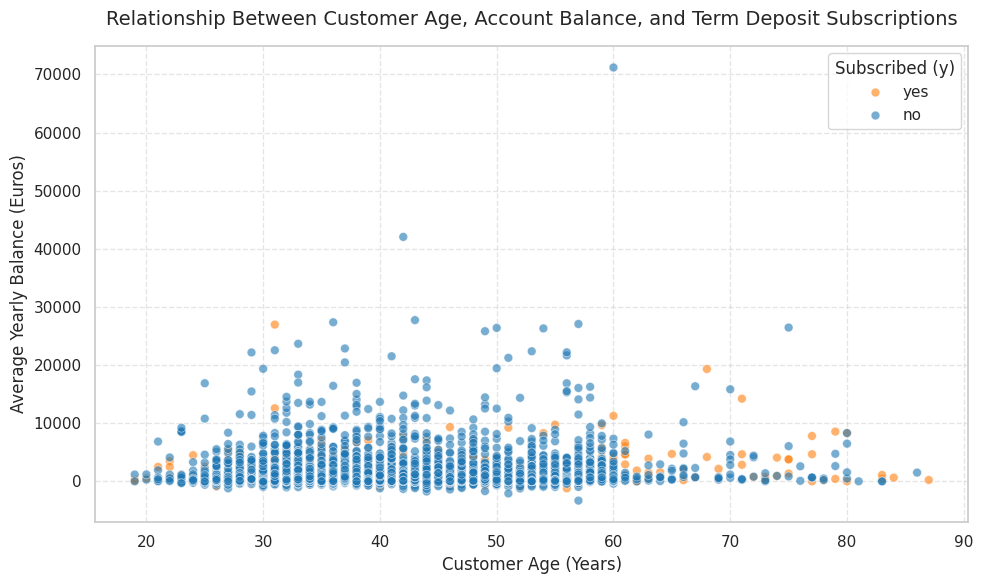

In [12]:
plt.figure(figsize=(10, 6))

# Sort data to ensure 'yes' points are plotted on top for better visibility
df_sorted = df.sort_values('y', ascending=False)

sns.scatterplot(
    x='age',
    y='balance',
    hue='y',
    data=df_sorted,
    palette={'no': '#1f77b4', 'yes': '#ff7f0e'},
    alpha=0.6,    # Add transparency to handle overplotting
    s=40,         # Reduce marker size
    edgecolor='w', # Add thin white edge to separate points
    linewidth=0.5
)

plt.title('Relationship Between Customer Age, Account Balance, and Term Deposit Subscriptions', fontsize=14, pad=15)
plt.xlabel('Customer Age (Years)', fontsize=12)
plt.ylabel('Average Yearly Balance (Euros)', fontsize=12)
plt.legend(title='Subscribed (y)', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
class OneRClassifier:
    def __init__(self, max_bins=4):
        self.max_bins = max_bins

    def _transform_feature(self, series, feature_name, fit=False):
        if pd.api.types.is_numeric_dtype(series):
            unique_count = series.nunique(dropna=False)

            if unique_count <= 1:
                bins = np.array([-np.inf, np.inf], dtype=float)
            elif fit:
                _, bins = pd.qcut(
                    series,
                    q=min(self.max_bins, unique_count),
                    duplicates="drop",
                    retbins=True,
                )
                bins[0] = -np.inf
                bins[-1] = np.inf
            else:
                bins = self.bin_edges_[feature_name]

            if fit:
                self.bin_edges_[feature_name] = bins

            transformed = pd.cut(series, bins=bins, include_lowest=True)
            return transformed.astype(str)

        return series.astype(str)

    def fit(self, X, y):
        X = X.copy()
        y = pd.Series(y).reset_index(drop=True)

        self.default_class_ = int(y.mode().iloc[0])
        self.default_positive_rate_ = float(y.mean())
        self.bin_edges_ = {}

        best_error = None
        best_payload = None

        for feature_name in X.columns:
            transformed = self._transform_feature(X[feature_name], feature_name, fit=True).reset_index(drop=True)

            grouped = pd.DataFrame({"feature": transformed, "target": y})
            rule_table = grouped.groupby("feature")["target"].agg(["count", "sum"])
            rule_table["positive_rate"] = rule_table["sum"] / rule_table["count"]
            rule_table["prediction"] = (rule_table["positive_rate"] >= 0.5).astype(int)

            predictions = transformed.map(rule_table["prediction"]).fillna(self.default_class_).astype(int)
            error_rate = float((predictions.to_numpy() != y.to_numpy()).mean())

            if best_error is None or error_rate < best_error:
                best_error = error_rate
                best_payload = {
                    "best_feature": feature_name,
                    "rule_map": rule_table["prediction"].to_dict(),
                    "proba_map": rule_table["positive_rate"].to_dict(),
                    "rule_table": rule_table.reset_index().sort_values("count", ascending=False),
                }

        self.best_feature_ = best_payload["best_feature"]
        self.rule_map_ = best_payload["rule_map"]
        self.proba_map_ = best_payload["proba_map"]
        self.rule_table_ = best_payload["rule_table"]
        self.training_error_ = best_error
        return self

    def _best_feature_values(self, X):
        return self._transform_feature(X[self.best_feature_], self.best_feature_, fit=False)

    def predict(self, X):
        values = self._best_feature_values(X)
        return values.map(self.rule_map_).fillna(self.default_class_).astype(int).to_numpy()

    def predict_proba(self, X):
        values = self._best_feature_values(X)
        positive_scores = values.map(self.proba_map_).fillna(self.default_positive_rate_).astype(float).to_numpy()
        negative_scores = 1.0 - positive_scores
        return np.column_stack([negative_scores, positive_scores])


def collect_metrics(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "TPR": tpr,
        "TNR": tnr,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "ConfusionMatrix": np.array([[tn, fp], [fn, tp]]),
    }


def evaluate_model(name, model, X_train_used, X_test_used):
    model.fit(X_train_used, y_train)
    y_pred = model.predict(X_test_used)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_used)[:, 1]
    else:
        y_score = y_pred.astype(float)

    metrics = collect_metrics(y_test, y_pred, y_score)
    metrics["Model"] = name

    return model, metrics, y_pred, y_score


In [14]:
models = {
    "Decision Tree": (
        DecisionTreeClassifier(
            criterion="entropy",
            max_depth=5,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42,
        ),
        X_train_encoded,
        X_test_encoded,
    ),
    "Rule-Based (OneR)": (
        OneRClassifier(max_bins=4),
        X_train_raw,
        X_test_raw,
    ),
    "KNN": (
        KNeighborsClassifier(n_neighbors=25, weights="distance"),
        X_train_scaled,
        X_test_scaled,
    ),
    "Naive Bayes": (
        GaussianNB(),
        X_train_scaled,
        X_test_scaled,
    ),
}

trained_models = {}
predictions = {}
scores = {}
evaluation_rows = []

for model_name, (model, X_train_used, X_test_used) in models.items():
    trained_model, metrics, y_pred, y_score = evaluate_model(
        model_name,
        model,
        X_train_used,
        X_test_used,
    )

    trained_models[model_name] = trained_model
    predictions[model_name] = y_pred
    scores[model_name] = y_score
    evaluation_rows.append(metrics)

results_df = (
    pd.DataFrame(evaluation_rows)
    .drop(columns=["ConfusionMatrix"])
    .sort_values(by=["F1", "ROC_AUC", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(
    results_df.style.format(
        {
            "Accuracy": "{:.3f}",
            "TPR": "{:.3f}",
            "TNR": "{:.3f}",
            "FPR": "{:.3f}",
            "FNR": "{:.3f}",
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1": "{:.3f}",
            "ROC_AUC": "{:.3f}",
        }
    )
)

print("Decision Tree rule excerpt:")
print(export_text(trained_models["Decision Tree"], feature_names=list(X_train_encoded.columns), max_depth=3))
print()
print(f"OneR selected feature: {trained_models['Rule-Based (OneR)'].best_feature_}")
display(trained_models["Rule-Based (OneR)"].rule_table_.head(10))


,Accuracy,TPR,TNR,FPR,FNR,Precision,Recall,F1,ROC_AUC,Model
0,0.825,0.375,0.884,0.116,0.625,0.295,0.375,0.331,0.712,Naive Bayes
1,0.768,0.423,0.813,0.187,0.577,0.227,0.423,0.295,0.679,Decision Tree
2,0.892,0.173,0.985,0.015,0.827,0.600,0.173,0.269,0.609,Rule-Based (OneR)
3,0.884,0.000,0.999,0.001,1.000,0.000,0.000,0.000,0.677,KNN


Decision Tree rule excerpt:
|--- poutcome_success <= 0.50
|   |--- contact_unknown <= 0.50
|   |   |--- month_oct <= 0.50
|   |   |   |--- month_jun <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- month_jun >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- month_oct >  0.50
|   |   |   |--- day <= 17.00
|   |   |   |   |--- class: 1
|   |   |   |--- day >  17.00
|   |   |   |   |--- class: 1
|   |--- contact_unknown >  0.50
|   |   |--- job_services <= 0.50
|   |   |   |--- age <= 58.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- age >  58.50
|   |   |   |   |--- class: 1
|   |   |--- job_services >  0.50
|   |   |   |--- day <= 6.50
|   |   |   |   |--- class: 0
|   |   |   |--- day >  6.50
|   |   |   |   |--- class: 0
|--- poutcome_success >  0.50
|   |--- day <= 16.50
|   |   |--- balance <= 958.50
|   |   |   |--- class: 1
|   |   |--- balance >  958.50
|   |   |   |--- class: 1
|   |--- day >  16.50
|   |   |--- 

,feature,count,sum,positive_rate,prediction
3,unknown,2947,268,0.090940,0
0,failure,404,52,0.128713,0
1,other,166,32,0.192771,0
2,success,99,65,0.656566,1


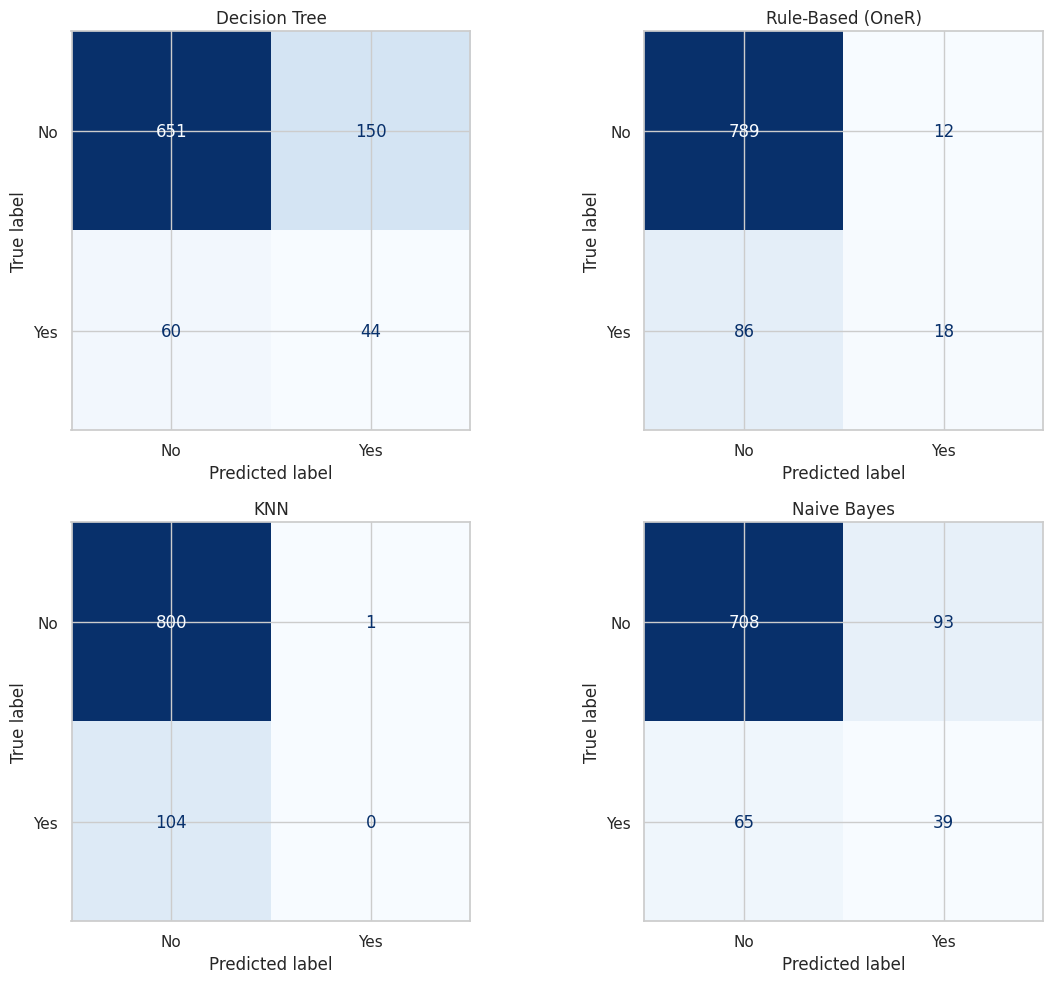

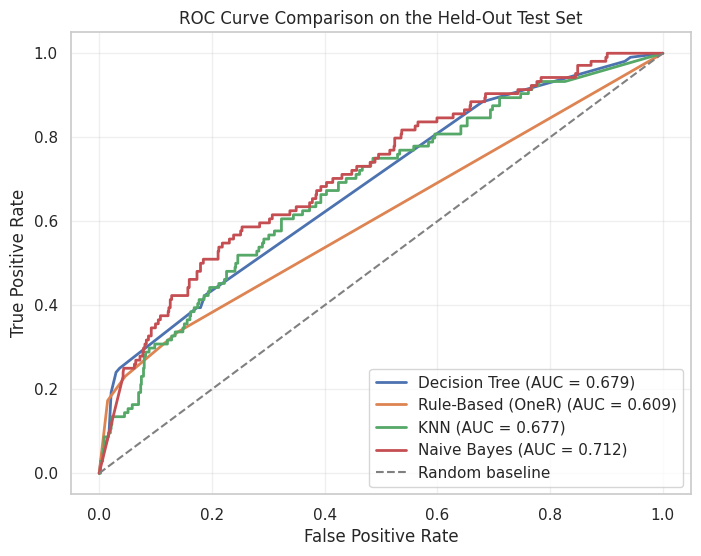

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (model_name, metrics_row) in zip(axes.flat, ((row["Model"], row) for row in evaluation_rows)):
    ConfusionMatrixDisplay(
        confusion_matrix=metrics_row["ConfusionMatrix"],
        display_labels=["No", "Yes"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

for row in evaluation_rows:
    model_name = row["Model"]
    fpr, tpr, _ = roc_curve(y_test, scores[model_name])
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {row['ROC_AUC']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.title("ROC Curve Comparison on the Held-Out Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


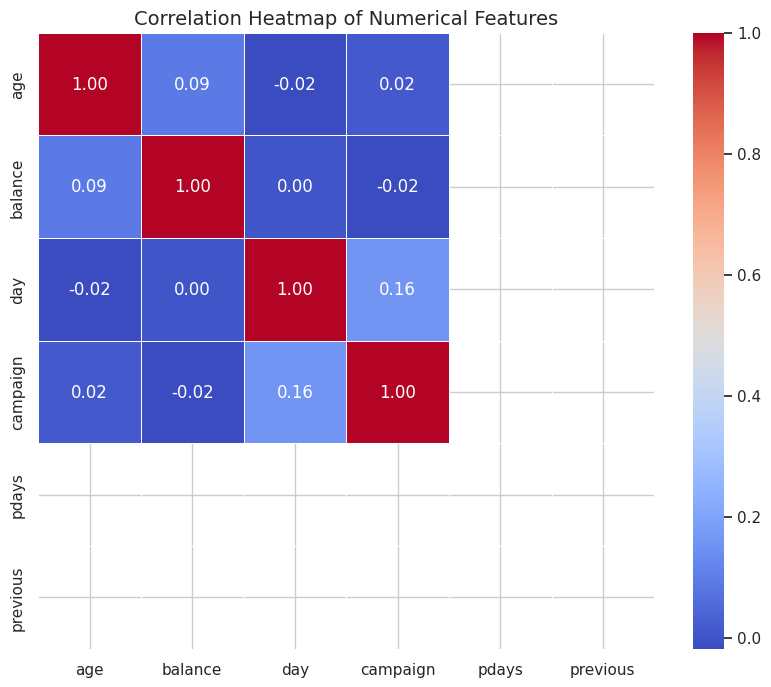

In [16]:
plt.figure(figsize=(10, 8))
correlation_matrix = X[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()